In [19]:
from src.mesh import Mesh3D
import numpy as np
from skimage.measure import marching_cubes
import pyvista as pv
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [20]:
euler_cube = np.load('./output/euler_cube.npy')
coord_cube = np.load('./output/coord_cube.npy')
Nb_cube = np.load('./output/Nb_cube.npy')
Sn_cube = np.load('./output/Sn_cube.npy')
points = np.load('./output/points.npy')
euler_flat = np.load('./output/euler_flat.npy')
Sn_flat = np.load('./output/Sn_flat.npy')
Nb_flat = np.load('./output/Nb_flat.npy')
Sn_points = np.copy(points)
phase_flat = np.load('./output/phase_flat.npy')

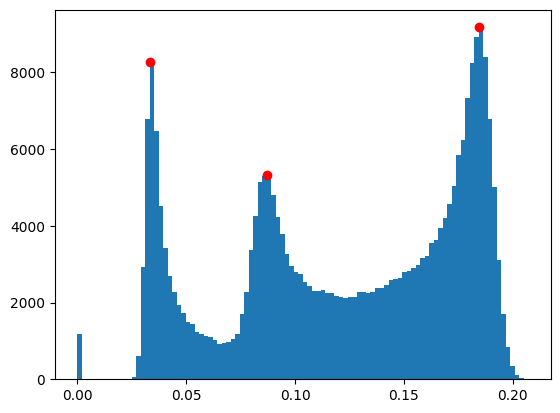

In [21]:
counts, bin_edges, patches = plt.hist(Sn_flat / (Nb_flat + Sn_flat + 1), bins=100)
peaks, _ = find_peaks(counts, height=4000)
plt.scatter(bin_edges[peaks], counts[peaks], c="red")
vacuum, lower_Sn_peak, upper_Sn_peak = bin_edges[peaks]

In [22]:
"""Find the vacuum interface"""


total_xray_cube = Nb_cube + Sn_cube
total_xray_cube = np.pad(total_xray_cube, pad_width=10, mode='edge')
Nb_cube = np.pad(Nb_cube, pad_width=10, mode='edge')

verts, faces, normals, values = marching_cubes(total_xray_cube,120000,spacing=(0.1,0.1,0.1))
verts = verts - np.array((1.0,1.0,1.0))
surface_mesh = pv.PolyData.from_regular_faces(verts, faces).subdivide(1).smooth(n_iter=10, relaxation_factor=0.1, boundary_smoothing=False).compute_normals(auto_orient_normals=True).triangulate()

verts, faces, normals, values = marching_cubes(Nb_cube,165000,spacing=(0.1,0.1,0.1))
verts = verts - np.array((1.0,1.0,1.0))
substrate_mesh = pv.PolyData.from_regular_faces(verts, faces).smooth(n_iter=20, relaxation_factor=0.1, boundary_smoothing=False).compute_normals(auto_orient_normals=True).triangulate()

"""Find points in vacuum"""
points_pv = pv.PolyData(points)
outside_points = points_pv.select_enclosed_points(surface_mesh.extrude([-10.0,0.0,0.0], capping=True), inside_out=True)
outside_mask = outside_points['SelectedPoints'].view(np.bool_)

phase_flat[outside_mask] = 3    # 3 -> Vacuum

point_data = {
    "euler": euler_flat,
    "phase": phase_flat
}

bounds = np.array(((0.0, 0.1*coord_cube.shape[0]),
        (0.0, 0.1*coord_cube.shape[1]),
        (0.0, 0.1*coord_cube.shape[2])))

mesh = Mesh3D(points, point_data, bounds)

/home/vike/dev/3debsd/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_array is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


In [23]:
surface = np.mean(surface_mesh.points[:,0])
substrate = np.mean(substrate_mesh.points[:,0])

In [24]:
import numpy as np
import pyvista as pv
from scipy.interpolate import griddata

bbox = bounds

# Step 1: Create or load your point cloud (replace this with your own data)
# For demonstration, we generate a sample 3D point cloud with a scalar
points = Sn_points  # 500 random points in 3D space
scalars = Sn_flat # Example scalar

# Step 2: Define a plane through the dataset
# Define a grid in the XY plane at the average Z value
plane_x = 2.7
grid_y, grid_z = np.meshgrid(np.linspace(bbox[1][0]-0.1, bbox[1][1]+0.1, 100), np.linspace(bbox[2][0]-0.1, bbox[2][1]+0.1, 100))
grid_x = np.full_like(grid_y, plane_x)
grid_points = np.c_[grid_x.ravel(), grid_y.ravel(), grid_z.ravel()]

# Step 3: Interpolate the scalar values onto the plane
interpolated_scalars = griddata(points, scalars, grid_points, method='linear')

# Step 4: Create a PyVista StructuredGrid
# Reshape the grid points and scalars to 2D grid
structured_grid = pv.StructuredGrid()
structured_grid.points = np.c_[grid_x.ravel(), grid_y.ravel(), grid_z.ravel()]
structured_grid.dimensions = grid_x.shape + (1,)
structured_grid["interpolated_scalar"] = interpolated_scalars

In [25]:
def calculate_sn_vs_dist():
    dist = [[]]
    count = [[]]

    for id in range(len(mesh.grains)):
        if (mesh.grain_phase[id] == 3).any():
            continue
        if (mesh.grain_phase[id] == 1).any():
            continue
        if len(mesh.grains[id]) > 10:
            grain_mesh = mesh.plot_grain(id)
            intersection = grain_mesh.intersection(structured_grid.extract_surface().triangulate(), split_first=False, split_second=False)[0]

            if intersection.n_points > 0:

                inside_grid = structured_grid.clip_surface(grain_mesh)

                if inside_grid.n_points > 0:

                    point_distances = inside_grid.compute_implicit_distance(grain_mesh)['implicit_distance']

                    dist.append(point_distances)
                    count.append(inside_grid['interpolated_scalar'])

    dist = np.concatenate(dist)
    count = np.concatenate(count)

    valid_mask = ~(np.isnan(dist)+np.isnan(count))

    dist = dist[valid_mask]
    count = count[valid_mask]

    return dist, count

In [26]:
from scipy.interpolate import RegularGridInterpolator

shape = Sn_cube.shape

x = np.linspace(bounds[0,0], bounds[0,1], shape[0])
y = np.linspace(bounds[1,0], bounds[1,1], shape[1])
z = np.linspace(bounds[2,0], bounds[2,1], shape[2])

data = Sn_cube

interp = RegularGridInterpolator((x, y, z), data, bounds_error=False)

In [27]:
grain_phases = np.array([arr[0] if arr.size > 0 else 0 for arr in mesh.grain_phase])

In [28]:
heterophase_faces = np.logical_and(mesh.T_FG[:, np.where(grain_phases == 2, True, False)].sum(axis = 1), mesh.T_FG[:, np.where(grain_phases != 2, True, False)].sum(axis = 1))

In [29]:
heterophase_faces

array([False, False, False, ..., False, False, False], shape=(567713,))

In [30]:
(np.logical_and(mesh.T_FG[:, np.where(grain_phases == 2, True, False)].sum(axis = 1), ~heterophase_faces)).nonzero()

(array([   420,    421,    944, ..., 567619, 567620, 567621],
       shape=(27088,)),)

In [31]:
nb3_sn_gbs = np.logical_and(mesh.T_FG[:, np.where(grain_phases == 2, True, False)].sum(axis = 1), ~heterophase_faces)

In [32]:
nb3_sn_gbs.nonzero()

(array([   420,    421,    944, ..., 567619, 567620, 567621],
       shape=(27088,)),)

In [33]:

GB_vertices = [mesh.vor.ridge_vertices[face] for face in nb3_sn_gbs.nonzero()[0]]

# First, identify which vertices are actually used in GB_vertices
used_vertices = set()
for triangle in GB_vertices:
    for idx in triangle:
        used_vertices.add(idx)

# Create a mapping from old indices to new indices
old_to_new = {}
new_vertices = []

for i, idx in enumerate(sorted(used_vertices)):
    old_to_new[idx] = i
    new_vertices.append(mesh.vertices[idx])

# Convert vertices to numpy array
new_vertices = np.array(new_vertices)

# Update the indices in GB_vertices
new_GB_vertices = []
for triangle in GB_vertices:
    new_triangle = [old_to_new[idx] for idx in triangle]
    new_GB_vertices.append(new_triangle)

grain_mesh = pv.PolyData.from_irregular_faces(new_vertices, new_GB_vertices).connectivity('largest').triangulate().clean().compute_normals(auto_orient_normals=True)  


nb3sn_gb_mesh = grain_mesh

In [34]:
plotter = pv.Plotter()

plotter.add_mesh(nb3sn_gb_mesh)

plotter.show()

Widget(value='<iframe src="http://localhost:46123/index.html?ui=P_0x7e296f3bd7f0_0&reconnect=auto" class="pyvi…

 JS Error => error: Uncaught TypeError: Cannot mix BigInt and other types, use explicit conversions


In [35]:
gb_dist = np.abs(pv.StructuredGrid(points).compute_implicit_distance(nb3sn_gb_mesh)['implicit_distance'])

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(100, 100)),
 array([0.        , 0.00897373, 0.01794745, 0.02692118, 0.03589491,
        0.04486864, 0.05384236, 0.06281609, 0.07178982, 0.08076354,
        0.08973727, 0.098711  , 0.10768473, 0.11665845, 0.12563218,
        0.13460591, 0.14357963, 0.15255336, 0.16152709, 0.17050081,
        0.17947454, 0.18844827, 0.197422  , 0.20639572, 0.21536945,
        0.22434318, 0.2333169 , 0.24229063, 0.25126436, 0.26023809,
        0.26921181, 0.27818554, 0.28715927, 0.29613299, 0.30510672,
        0.31408045, 0.32305418, 0.3320279 , 0.34100163, 0.34997536,
        0.35894908, 0.36792281, 0.37689654, 0.38587026, 0.39484399,
        0.40381772, 0.41279145, 0.42176517, 0.4307389 , 0.43971263,
        0.44868635, 0.45766008, 0.46663381, 0.4756075

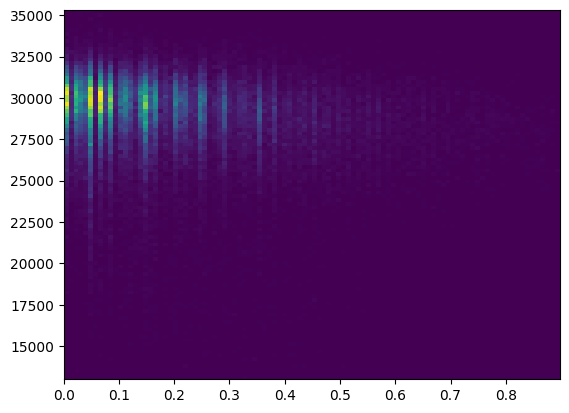

In [36]:
plt.hist2d(gb_dist[np.where(np.abs(points[:,0] - 3.0) < 0.5)], Sn_flat[np.where(np.abs(points[:,0] - 3.0) < 0.5)], bins=(100,100))

In [48]:
def calculate_sn_vs_dist(x_plane, window):
    # Define bin edges
    x_bins = np.linspace(0.0,0.6, 501)   # 100 bins in x
    y_bins = np.linspace(0.0,1.2, 501)   # 100 bins in y


    predicate = np.where(np.abs(points[:,0] - x_plane) < window)

    Sn_percent = Sn_flat[predicate] / (Sn_flat[predicate] + Nb_flat[predicate])

    # Compute 2D histogram
    H, x_edges, y_edges = np.histogram2d(gb_dist[predicate], 0.25 * (Sn_percent - lower_Sn_peak) / (upper_Sn_peak - lower_Sn_peak), bins=[x_bins, y_bins])

    return H, x_edges, y_edges

/tmp/ipykernel_8565/3500983608.py:9: RuntimeWarning: invalid value encountered in divide
  Sn_percent = Sn_flat[predicate] / (Sn_flat[predicate] + Nb_flat[predicate])


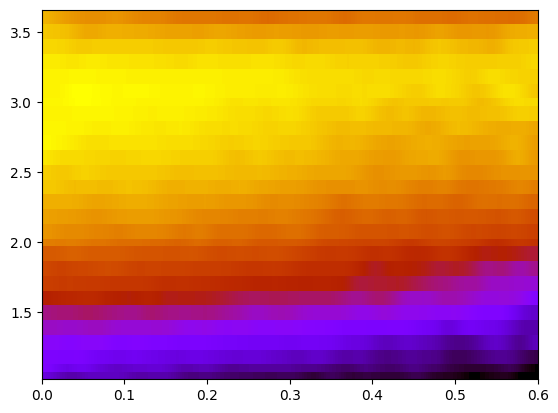

In [49]:
from scipy.ndimage import gaussian_filter


# Create a figure and 3D axes
fig = plt.figure()
ax = fig.add_subplot(111)

n_slices = 50

x_slices = np.linspace(substrate, surface, num=n_slices)

xs = []
ys = []
data = []

for i in range(n_slices):

    plane_x = x_slices[i]

    # Compute 2D histogram
    H, x_edges, y_edges = calculate_sn_vs_dist(plane_x, 0.1)

    # Normalize each column so it sums to 1
    H_norm = H / (H.sum(axis=1, keepdims=True) + 1e-12)  # avoid division by zero

    H_norm = gaussian_filter(H_norm, 10.0)

    x_centers = (x_edges[:-1] + x_edges[1:]) / 2
    y_centers = (y_edges[:-1] + y_edges[1:]) / 2

    y_avg = np.sum(H_norm*y_centers, axis=1) / np.sum(H_norm, axis=1)

    # y_avg /= np.mean(y_avg)


    xs.append(x_centers)
    ys.append(np.repeat([plane_x], 500))
    data.append(y_avg)

xs = np.stack(xs)
ys = np.stack(ys)
data = np.stack(data)

ax.pcolormesh(xs, ys, data, cmap='gnuplot')

2025-11-18 15:50:32.211 ( 669.627s) [    78DA45530100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-11-18 15:50:32.483 ( 669.899s) [    78DA45530100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-11-18 15:50:33.072 ( 670.489s) [    78DA45530100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-11-18 15:50:33.269 ( 670.685s) [    78DA45530100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-11-18 15:50:33.410 ( 670.826s) [    78DA45530100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-11-18 15:50:33.483 ( 670.899s) [    78DA45530100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-11-18 15:50:33.500 ( 670.916s) [    78DA45530100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-11-18 15:50:33.587 ( 671.003s) [    78DA45530100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-11-18 15:50

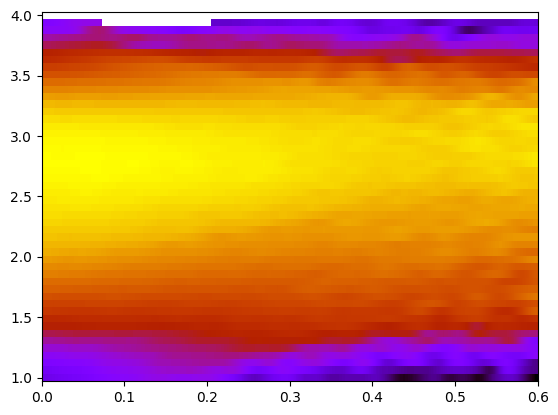

In [17]:
from scipy.ndimage import gaussian_filter


# Create a figure and 3D axes
fig = plt.figure()
ax = fig.add_subplot(111)

n_slices = 50

x_slices = np.linspace(1.0, 4.0, num=n_slices)

xs = []
ys = []
data = []

for i in range(n_slices):

    plane_x = x_slices[i]
    grid_y, grid_z = np.meshgrid(np.linspace(bbox[1][0]-0.1, bbox[1][1]+0.1, 100), np.linspace(bbox[2][0]-0.1, bbox[2][1]+0.1, 100))
    grid_x = np.full_like(grid_y, plane_x)
    grid_points = np.c_[grid_x.ravel(), grid_y.ravel(), grid_z.ravel()]


    # Find the indices of points where the z-coordinate is within the range
    # indices = np.where((points[:, 0] >= plane_x - 0.5) & (points[:, 0] <= plane_x + 0.5))

    # interpolated_scalars = griddata(points[indices], scalars[indices], grid_points, method='nearest')
    interpolated_scalars = interp(grid_points)

    structured_grid = pv.StructuredGrid()
    structured_grid.points = np.c_[grid_x.ravel(), grid_y.ravel(), grid_z.ravel()]
    structured_grid.dimensions = grid_x.shape + (1,)
    structured_grid["interpolated_scalar"] = interpolated_scalars

    dist, count = calculate_sn_vs_dist()

    # Define bin edges
    x_bins = np.linspace(0.0,0.6, 501)   # 100 bins in x
    y_bins = np.linspace(0.0,1.2, 501)   # 100 bins in y

    # Compute 2D histogram
    H, x_edges, y_edges = np.histogram2d(np.abs(dist), (count-lower_Sn_peak)/(upper_Sn_peak-lower_Sn_peak), bins=[x_bins, y_bins])

    # Normalize each column so it sums to 1
    H_norm = H / (H.sum(axis=1, keepdims=True) + 1e-12)  # avoid division by zero

    H_norm = gaussian_filter(H_norm, 10.0)

    y_avg = np.sum(H_norm*y_bins[None,:-1],axis=1) / np.sum(H_norm,axis=1)
    x_centers = (x_edges[:-1] + x_edges[1:]) / 2

    xs.append(x_centers)
    ys.append(np.repeat([plane_x], 500))
    data.append(y_avg)

xs = np.stack(xs)
ys = np.stack(ys)
data = np.stack(data)

ax.pcolormesh(xs, ys, data, cmap='gnuplot')



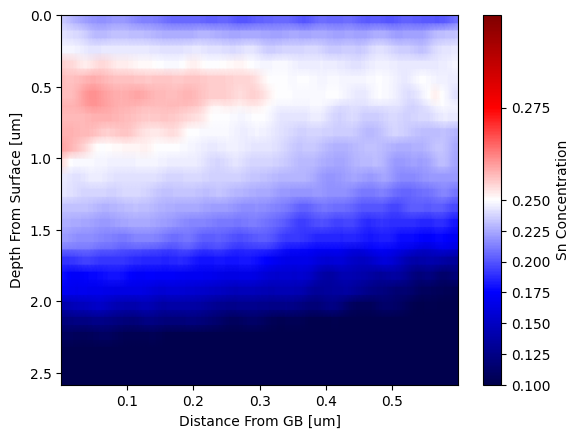

In [55]:
# Create a figure and 3D axes
from matplotlib.colors import TwoSlopeNorm, LogNorm


fig = plt.figure()
ax = fig.add_subplot(111)


# Define colormap normalization
vmin = 0.10
vmax = 0.30
center = 0.25  # this will be the "center" of the colormap
norm = TwoSlopeNorm(vmin=vmin, vcenter=center, vmax=vmax)
# norm = LogNorm(vmin=vmin, vmax=vmax, )

pcm = ax.pcolormesh(xs, surface-ys, data, cmap='seismic', shading="gouraud", norm=norm)
ax.invert_yaxis()

ax.set_ylabel("Depth From Surface [um]")
ax.set_xlabel("Distance From GB [um]")

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label("Sn Concentration")

fig.savefig("./depth_analysis.png")